In [1]:
import numpy as np

eeg_test = np.load(r"D:\22\AA\preprocess\preprocessed_FFinal\_test_subs.npy", allow_pickle=True).tolist()
e4_test  = np.load(r"D:\22\AA\preprocess\preprocessed_E4_v3_BHT\_test_subs.npy", allow_pickle=True).tolist()

print("EEG test:", sorted(eeg_test))
print("E4  test:", sorted(e4_test))
print("Same?", sorted(eeg_test) == sorted(e4_test))

EEG test: ['sub-005', 'sub-007', 'sub-014', 'sub-017', 'sub-019', 'sub-023', 'sub-035', 'sub-036', 'sub-038', 'sub-040', 'sub-045', 'sub-068', 'sub-081', 'sub-087', 'sub-093', 'sub-100', 'sub-104', 'sub-105', 'sub-112', 'sub-121']
E4  test: ['sub-005', 'sub-007', 'sub-014', 'sub-017', 'sub-019', 'sub-023', 'sub-035', 'sub-036', 'sub-038', 'sub-040', 'sub-045', 'sub-068', 'sub-081', 'sub-087', 'sub-093', 'sub-104', 'sub-105', 'sub-112', 'sub-121']
Same? False


Device       : cuda
EEG ckpt dir : D:\22\AA\evaluation\bitMamSleep_supcon_c7
E4  ckpt dir : D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon
Output       : D:\22\AA\evaluation\fusion_EEG_E4

EEG test subs : 20
E4  test subs : 19
Common test   : 19
COMMON_TEST   : ['sub-005', 'sub-007', 'sub-014', 'sub-017', 'sub-019', 'sub-023', 'sub-035', 'sub-036', 'sub-038', 'sub-040', 'sub-045', 'sub-068', 'sub-081', 'sub-087', 'sub-093', 'sub-104', 'sub-105', 'sub-112', 'sub-121']

Loading EEG test dataset...
EEG test samples: 18,898

Loading E4 test dataset...
E4  test samples: 18,899
EEG test samples: 18,898  E4 test samples: 18,899
  ⚠ Count differs by 1 — will align after inference
✓ Sample count matched!

Loading EEG models from: D:\22\AA\evaluation\bitMamSleep_supcon_c7
  ✓ EEG seed=42
  ✓ EEG seed=123
  ✓ EEG seed=256
  ✓ EEG seed=789
  ✓ EEG seed=999

Loading E4 models from: D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon
  ✓ E4  seed=42
  ✓ E4  seed=123
  ✓ E4  seed=256
  ✓ E4  seed=789
  ✓ E4

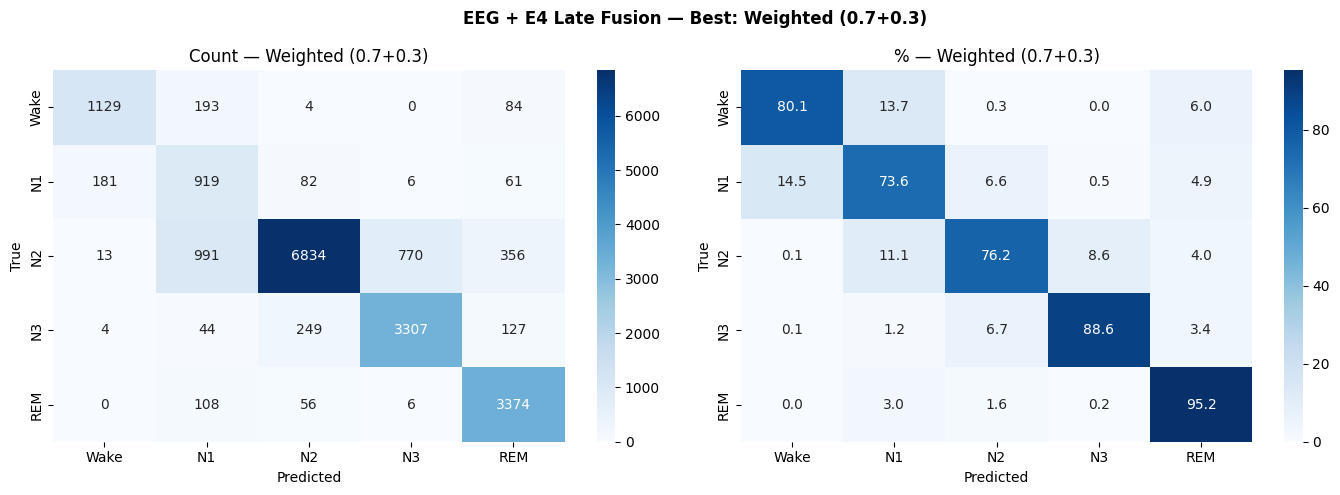

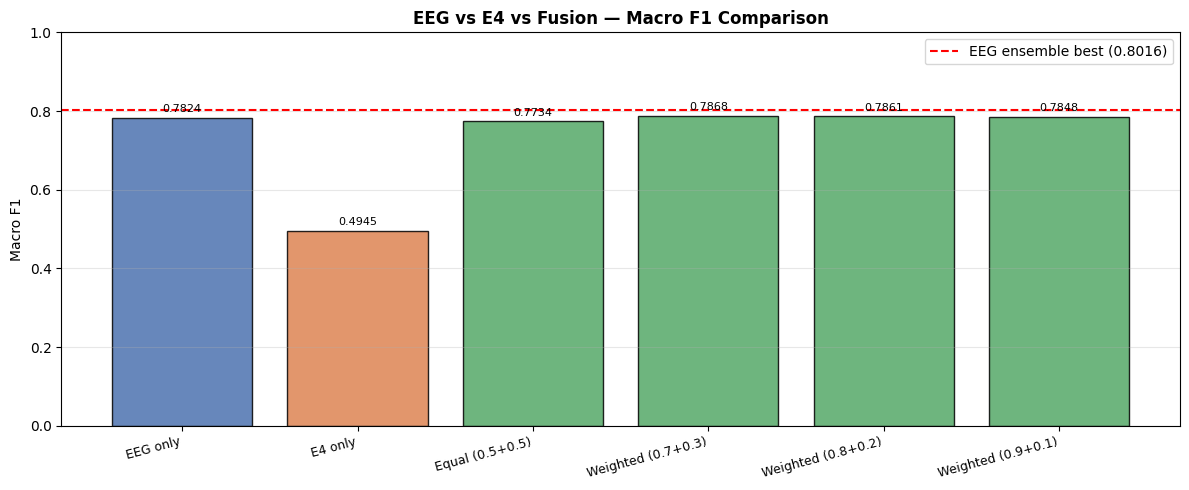


Outputs saved: D:\22\AA\evaluation\fusion_EEG_E4
Done!


In [8]:
# ============================================================
# Late Fusion: EEG (BiT-MamSleep) + E4 (BiT-MamSleep)
# 
# EEG: 5 seeds, 19 common test subjects (sub-100 excluded)
# E4 : 5 seeds, 19 test subjects
# 
# Fusion variants:
#   1. EEG only ensemble      (baseline)
#   2. E4 only ensemble       (baseline)
#   3. Equal fusion           (EEG×0.5 + E4×0.5)
#   4. Weighted fusion        (EEG×0.7 + E4×0.3)
#   5. Weighted fusion        (EEG×0.8 + E4×0.2)
#   6. Weighted fusion        (EEG×0.9 + E4×0.1)
# ============================================================

import os
import math
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
EEG_DATA_PATH  = r"D:\22\AA\preprocess\preprocessed_FFinal"
E4_DATA_PATH   = r"D:\22\AA\preprocess\preprocessed_E4_v3_BHT"
ARTIFACT_PATH  = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"

EEG_CKPT_DIR   = r"D:\22\AA\evaluation\bitMamSleep_supcon_c7"
E4_CKPT_DIR    = r"D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon"

EVAL_PATH      = r"D:\22\AA\evaluation\fusion_EEG_E4"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES    = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT        = 7
WINDOW         = 2 * CONTEXT + 1
BATCH_SIZE     = 64
SEEDS          = [42, 123, 256, 789, 999]

# EEG config
EEG_IN_CH      = 3
EEG_EPOCH_SAMP = 7680   # 256Hz × 30s
EEG_D_MODEL    = 128
EEG_D_STATE    = 16

# E4 config
E4_IN_CH       = 3
E4_EPOCH_SAMP  = 1920   # 64Hz × 30s
E4_D_MODEL     = 128
E4_D_STATE     = 16

DROPOUT        = 0.4
PROJ_DIM       = 64

ARTIFACT_WEIGHT_MAP   = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_ART_CHANNELS   = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_ART_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {device}")
print(f"EEG ckpt dir : {EEG_CKPT_DIR}")
print(f"E4  ckpt dir : {E4_CKPT_DIR}")
print(f"Output       : {EVAL_PATH}")


# ============================================================
# COMMON TEST SUBJECTS (sub-100 excluded)
# ============================================================
eeg_test = np.load(os.path.join(EEG_DATA_PATH, "_test_subs.npy"), allow_pickle=True).tolist()
e4_test  = np.load(os.path.join(E4_DATA_PATH,  "_test_subs.npy"), allow_pickle=True).tolist()

COMMON_TEST = sorted([s for s in eeg_test if s in e4_test])
print(f"\nEEG test subs : {len(eeg_test)}")
print(f"E4  test subs : {len(e4_test)}")
print(f"Common test   : {len(COMMON_TEST)}")
print(f"COMMON_TEST   : {COMMON_TEST}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, n_epochs):
    tsv_path = os.path.join(
        ARTIFACT_PATH, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return np.ones(n_epochs, dtype=np.float32)
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return np.ones(n_epochs, dtype=np.float32)

    available = [ch for ch in TARGET_ART_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_ART_CHANNELS if ch in df.columns]
    if not available:
        return np.ones(n_epochs, dtype=np.float32)

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // 30).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    weights = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        idx = int(ep_idx)
        if 0 <= idx < n_epochs:
            weights[idx] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# EEG DATASET
# ============================================================
class EEGDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0],    :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n     = len(labels)
            art_w = load_artifact_weights(sub, n)

            sub_idx = len(self.data)
            self.data.append((signal, labels, art_w))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        signal, labels, _ = self.data[sub_idx]
        window = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window.append(signal[ei])
        x = np.stack(window, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


# ============================================================
# E4 DATASET
# ============================================================
class E4Dataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                e4     = d['e4'].astype(np.float32)
                labels = d['labels'].copy()
                art_w  = d['weights'].astype(np.float32) if 'weights' in d \
                         else load_artifact_weights(sub, len(labels))

            n       = len(labels)
            sub_idx = len(self.data)
            self.data.append((e4, labels, art_w))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        e4, labels, _ = self.data[sub_idx]
        window = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window.append(e4[ei])
        x = np.stack(window, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


print("\nLoading EEG test dataset...")
eeg_ds = EEGDataset(COMMON_TEST, EEG_DATA_PATH)
eeg_loader = DataLoader(eeg_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"EEG test samples: {len(eeg_ds):,}")

print("\nLoading E4 test dataset...")
e4_ds = E4Dataset(COMMON_TEST, E4_DATA_PATH)
e4_loader = DataLoader(e4_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"E4  test samples: {len(e4_ds):,}")

print(f"EEG test samples: {len(eeg_ds):,}  E4 test samples: {len(e4_ds):,}")
if len(eeg_ds) != len(e4_ds):
    print(f"  ⚠ Count differs by {abs(len(eeg_ds)-len(e4_ds))} — will align after inference")
    f"MISMATCH! EEG={len(eeg_ds)} E4={len(e4_ds)}"
print("✓ Sample count matched!")


# ============================================================
# MODEL CLASSES
# ============================================================
class TripleResCNN(nn.Module):
    def __init__(self, in_ch, d_model, dropout,
                 kernels=(25, 50, 100), stride=6, epoch_samples=7680,
                 inner_kernel=8, inner_padding=4):
        super().__init__()
        mid = d_model // 3

        def branch(k):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=k, stride=stride, padding=k//2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=inner_kernel, padding=inner_padding),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = branch(kernels[0])
        self.medium = branch(kernels[1])
        self.large  = branch(kernels[2])

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, epoch_samples)
            L = min(self.small(dummy).shape[2],
                    self.medium(dummy).shape[2],
                    self.large(dummy).shape[2])

        self.pool_s = nn.AdaptiveAvgPool1d(L)
        self.pool_m = nn.AdaptiveAvgPool1d(L)
        self.pool_l = nn.AdaptiveAvgPool1d(L)
        self.proj   = nn.Sequential(
            nn.Conv1d(3*mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))
        return self.proj(torch.cat([fs, fm, fl], dim=1))


class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state, d_conv=4, expand=2, dropout=0.4):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand
        self.in_proj = nn.Linear(d_model, self.d_inner*2, bias=False)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv-1,
            groups=self.d_inner, bias=True
        )
        self.x_proj  = nn.Linear(self.d_inner, d_state*2+1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)
        A = torch.arange(1, d_state+1, dtype=torch.float32).unsqueeze(0)
        self.A_log   = nn.Parameter(torch.log(A.expand(self.d_inner, -1)))
        self.D       = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_s, L, d = x.shape
        h  = torch.zeros(B_s, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            h  = h * A.unsqueeze(0) + xi.unsqueeze(-1) * B[:, i, :].unsqueeze(1)
            ys.append((h * C[:, i, :].unsqueeze(1)).sum(-1) + D * xi)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        B, L, _ = x.shape
        xz = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_ = F.silu(self.conv1d(x_.transpose(1,2))[:,:,:L].transpose(1,2))
        sp = self.x_proj(x_)
        dt_r, Bp, Cp = sp.split([1, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_r))
        A  = -torch.exp(self.A_log)
        A_disc = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)).mean(1).mean(0)
        y = self.ssm_scan(x_, A_disc, Bp, Cp, self.D)
        y = self.out_proj(self.dropout(y * F.silu(z)))
        return self.norm(y + x)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model, d_state, dropout=0.4):
        super().__init__()
        self.forward_mamba  = MambaBlock(d_model, d_state, dropout=dropout)
        self.backward_mamba = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.forward_mamba(x)
        bwd = torch.flip(self.backward_mamba(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class E4BiMambaBlock(nn.Module):
    """BiMamba with fwd/bwd names — matches E4 checkpoint"""
    def __init__(self, d_model, d_state, dropout=0.4):
        super().__init__()
        self.fwd  = MambaBlock(d_model, d_state, dropout=dropout)
        self.bwd  = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.fwd(x)
        bwd = torch.flip(self.bwd(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class BitMamSleepModel(nn.Module):
    def __init__(self, in_ch, d_model, d_state, dropout,
                 n_layers=2, n_classes=5, context=CONTEXT,
                 proj_dim=PROJ_DIM, kernels=(25,50,100),
                 stride=6, epoch_samples=7680,
                 inner_kernel=8, inner_padding=4,
                 bimamba_cls=None):
        super().__init__()
        self.context = context
        self.d_model = d_model
        if bimamba_cls is None:
            bimamba_cls = BiMambaBlock

        self.triple_cnn = TripleResCNN(
            in_ch, d_model, dropout,
            kernels=kernels, stride=stride, epoch_samples=epoch_samples,
            inner_kernel=inner_kernel, inner_padding=inner_padding
        )
        self.intra_bimamba = nn.Sequential(*[
            bimamba_cls(d_model, d_state, dropout) for _ in range(n_layers)
        ])
        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[
            bimamba_cls(d_model, d_state, dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn  = self.triple_cnn(x.view(B*W, C, T)).permute(0, 2, 1)
        intra = self.intra_bimamba(cnn).mean(dim=1).view(B, W, self.d_model)
        inter = self.inter_bimamba(intra + self.inter_pos)
        center = inter[:, self.context, :]
        return self.classifier(center), F.normalize(self.projector(center), dim=1)


# ============================================================
# LOAD EEG MODELS (5 seeds)
# ============================================================
print(f"\nLoading EEG models from: {EEG_CKPT_DIR}")
eeg_models = []
for seed in SEEDS:
    ckpt = os.path.join(EEG_CKPT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  ✗ NOT FOUND: {ckpt}")
        continue
    m = BitMamSleepModel(
        in_ch=EEG_IN_CH, d_model=EEG_D_MODEL, d_state=EEG_D_STATE,
        dropout=DROPOUT, epoch_samples=EEG_EPOCH_SAMP
    ).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    eeg_models.append(m)
    print(f"  ✓ EEG seed={seed}")

# ============================================================
# LOAD E4 MODELS (5 seeds)
# ============================================================
print(f"\nLoading E4 models from: {E4_CKPT_DIR}")
e4_models = []
for seed in SEEDS:
    ckpt = os.path.join(E4_CKPT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  ✗ NOT FOUND: {ckpt}")
        continue
    m = BitMamSleepModel(
        in_ch=E4_IN_CH, d_model=E4_D_MODEL, d_state=E4_D_STATE,
        dropout=DROPOUT,
        kernels=(7, 13, 25), stride=4,
        epoch_samples=E4_EPOCH_SAMP,
        inner_kernel=5, inner_padding=2,
        bimamba_cls=E4BiMambaBlock
    ).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    e4_models.append(m)
    print(f"  ✓ E4  seed={seed}")

print(f"\nEEG models: {len(eeg_models)}  E4 models: {len(e4_models)}")


# ============================================================
# GET PROBABILITIES
# ============================================================
def get_probs(models, loader):
    all_model_probs = []
    for model in models:
        model_probs = []
        with torch.no_grad():
            for x, y, w in loader:
                logits, _ = model(x.to(device))
                probs = F.softmax(logits, dim=1).cpu().numpy()
                model_probs.append(probs)
        all_model_probs.append(np.concatenate(model_probs, axis=0))
    return np.stack(all_model_probs, axis=0)   # (N_models, N, 5)


print("\nGetting EEG probabilities...")
eeg_probs_all = get_probs(eeg_models, eeg_loader)  # (5, N, 5)
print("Getting E4  probabilities...")
e4_probs_all  = get_probs(e4_models,  e4_loader)   # (5, N, 5)

# Ensemble averages
eeg_probs = eeg_probs_all.mean(axis=0)   # (N, 5)
e4_probs  = e4_probs_all.mean(axis=0)    # (N, 5)

# Collect labels and weights
all_labels  = []
all_weights = []
with torch.no_grad():
    for x, y, w in eeg_loader:
        all_labels.extend(y.numpy())
        all_weights.extend(w.numpy())
all_labels  = np.array(all_labels)
all_weights = np.array(all_weights)

# Align all to minimum length (EEG vs E4 may differ by 1-2 samples)
min_len     = min(len(eeg_probs), len(e4_probs), len(all_labels))
eeg_probs   = eeg_probs[:min_len]
e4_probs    = e4_probs[:min_len]
all_labels  = all_labels[:min_len]
all_weights = all_weights[:min_len]
print(f"✓ Aligned to {min_len} samples")


# ============================================================
# METRICS HELPER
# ============================================================
def metrics(preds, labels, weights):
    acc   = accuracy_score(labels, preds)
    f1    = f1_score(labels, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labels, preds)
    per   = f1_score(labels, preds, average=None, zero_division=0)
    cm    = (weights == 1.0)
    nm    = (weights > 0) & (weights < 1.0)
    c_acc = accuracy_score(labels[cm], preds[cm]) if cm.sum() > 0 else 0.0
    n_acc = accuracy_score(labels[nm], preds[nm]) if nm.sum() > 0 else 0.0
    return acc, f1, kappa, per, c_acc, n_acc

def print_metrics(title, preds, labels, weights):
    acc, f1, kappa, per, c_acc, n_acc = metrics(preds, labels, weights)
    print(f"\n{'='*55}")
    print(f"{title}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Macro F1    : {f1:.4f}")
    print(f"  Cohen Kappa : {kappa:.4f}")
    print(f"  Clean Acc   : {c_acc*100:.2f}%")
    print(f"  Noisy Acc   : {n_acc*100:.2f}%")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(per[i] * 16)
        print(f"    {name:6s}: {per[i]:.4f}  {bar}")
    return acc, f1, kappa, per


# ============================================================
# FUSION VARIANTS
# ============================================================
results = {}

# 1. EEG only
preds = eeg_probs.argmax(axis=1)
acc, f1, kappa, per = print_metrics("1. EEG only (ensemble)", preds, all_labels, all_weights)
results['EEG only'] = (acc, f1, kappa, per)

# 2. E4 only
preds = e4_probs.argmax(axis=1)
acc, f1, kappa, per = print_metrics("2. E4 only (ensemble)", preds, all_labels, all_weights)
results['E4 only'] = (acc, f1, kappa, per)

# 3. Equal fusion (0.5 + 0.5)
fused = 0.5 * eeg_probs + 0.5 * e4_probs
preds = fused.argmax(axis=1)
acc, f1, kappa, per = print_metrics("3. Equal fusion (EEG×0.5 + E4×0.5)", preds, all_labels, all_weights)
results['Equal (0.5+0.5)'] = (acc, f1, kappa, per)

# 4. Weighted (0.7 + 0.3)
fused = 0.7 * eeg_probs + 0.3 * e4_probs
preds = fused.argmax(axis=1)
acc, f1, kappa, per = print_metrics("4. Weighted (EEG×0.7 + E4×0.3)", preds, all_labels, all_weights)
results['Weighted (0.7+0.3)'] = (acc, f1, kappa, per)

# 5. Weighted (0.8 + 0.2)
fused = 0.8 * eeg_probs + 0.2 * e4_probs
preds = fused.argmax(axis=1)
acc, f1, kappa, per = print_metrics("5. Weighted (EEG×0.8 + E4×0.2)", preds, all_labels, all_weights)
results['Weighted (0.8+0.2)'] = (acc, f1, kappa, per)

# 6. Weighted (0.9 + 0.1)
fused = 0.9 * eeg_probs + 0.1 * e4_probs
preds = fused.argmax(axis=1)
acc, f1, kappa, per = print_metrics("6. Weighted (EEG×0.9 + E4×0.1)", preds, all_labels, all_weights)
results['Weighted (0.9+0.1)'] = (acc, f1, kappa, per)


# ============================================================
# FINAL COMPARISON TABLE
# ============================================================
print(f"\n{'='*65}")
print("FINAL COMPARISON TABLE")
print(f"{'='*65}")
print(f"{'Model':<35} {'Acc%':>7} {'F1':>7} {'N1':>7} {'Kappa':>7}")
print("-" * 65)

best_f1 = 0
for name, (acc, f1, kappa, per) in results.items():
    star = " ★" if f1 == max(r[1] for r in results.values()) else ""
    print(f"{name+star:<35} {acc*100:>7.2f} {f1:>7.4f} {per[1]:>7.4f} {kappa:>7.4f}")

print(f"{'='*65}")

# Find best fusion
best_name = max(results, key=lambda k: results[k][1])
best_acc, best_f1, best_kappa, best_per = results[best_name]
print(f"\nBest fusion: {best_name}")
print(f"  Acc={best_acc*100:.2f}%  F1={best_f1:.4f}  Kappa={best_kappa:.4f}")


# ============================================================
# CONFUSION MATRIX — best fusion
# ============================================================
w_map = {
    'EEG only':           (1.0, 0.0),
    'E4 only':            (0.0, 1.0),
    'Equal (0.5+0.5)':    (0.5, 0.5),
    'Weighted (0.7+0.3)': (0.7, 0.3),
    'Weighted (0.8+0.2)': (0.8, 0.2),
    'Weighted (0.9+0.1)': (0.9, 0.1),
}
w_eeg, w_e4 = w_map[best_name]
best_fused = w_eeg * eeg_probs + w_e4 * e4_probs
best_preds = best_fused.argmax(axis=1)

cm     = confusion_matrix(all_labels, best_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title(f"Count — {best_name}")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title(f"% — {best_name}")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle(f"EEG + E4 Late Fusion — Best: {best_name}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_fusion.png"), dpi=150)
plt.show()

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
f1s   = [results[n][1] for n in names]
colors = ['#4C72B0' if 'EEG only' in n else
          '#DD8452' if 'E4 only'  in n else '#55A868'
          for n in names]

bars = ax.bar(range(len(names)), f1s, color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1.0)
ax.set_title("EEG vs E4 vs Fusion — Macro F1 Comparison", fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.8016, color='red', ls='--', lw=1.5, label='EEG ensemble best (0.8016)')
ax.legend()

for bar, f1 in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{f1:.4f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "f1_comparison.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")

In [6]:
import torch

ckpt_eeg = r"D:\22\AA\evaluation\bitMamSleep_supcon_c7\best_seed42.pt"
ckpt_e4  = r"D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon\best_seed42.pt"

for path, name in [(ckpt_eeg, "EEG"), (ckpt_e4, "E4")]:
    sd   = torch.load(path, map_location='cpu')
    keys = list(sd.keys())
    print(f"\n{name} — first 10 keys:")
    for k in keys[:10]:
        print(f"  {k}  {sd[k].shape}")


EEG — first 10 keys:
  inter_pos  torch.Size([1, 15, 128])
  triple_cnn.small.0.weight  torch.Size([42, 3, 25])
  triple_cnn.small.0.bias  torch.Size([42])
  triple_cnn.small.1.weight  torch.Size([42])
  triple_cnn.small.1.bias  torch.Size([42])
  triple_cnn.small.1.running_mean  torch.Size([42])
  triple_cnn.small.1.running_var  torch.Size([42])
  triple_cnn.small.1.num_batches_tracked  torch.Size([])
  triple_cnn.small.4.weight  torch.Size([42, 42, 8])
  triple_cnn.small.4.bias  torch.Size([42])

E4 — first 10 keys:
  inter_pos  torch.Size([1, 15, 128])
  triple_cnn.small.0.weight  torch.Size([42, 3, 7])
  triple_cnn.small.0.bias  torch.Size([42])
  triple_cnn.small.1.weight  torch.Size([42])
  triple_cnn.small.1.bias  torch.Size([42])
  triple_cnn.small.1.running_mean  torch.Size([42])
  triple_cnn.small.1.running_var  torch.Size([42])
  triple_cnn.small.1.num_batches_tracked  torch.Size([])
  triple_cnn.small.4.weight  torch.Size([42, 42, 5])
  triple_cnn.small.4.bias  torch.Size(

In [7]:
import torch

ckpt_e4 = r"D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon\best_seed42.pt"
sd = torch.load(ckpt_e4, map_location='cpu')
keys = list(sd.keys())

# BiMamba related keys
bimamba_keys = [k for k in keys if 'bimamba' in k]
print("BiMamba keys in E4 checkpoint (first 10):")
for k in bimamba_keys[:10]:
    print(f"  {k}")

BiMamba keys in E4 checkpoint (first 10):
  intra_bimamba.0.fwd.A_log
  intra_bimamba.0.fwd.D
  intra_bimamba.0.fwd.in_proj.weight
  intra_bimamba.0.fwd.conv1d.weight
  intra_bimamba.0.fwd.conv1d.bias
  intra_bimamba.0.fwd.x_proj.weight
  intra_bimamba.0.fwd.dt_proj.weight
  intra_bimamba.0.fwd.dt_proj.bias
  intra_bimamba.0.fwd.out_proj.weight
  intra_bimamba.0.fwd.norm.weight
